# Warehouse & Retail Sales Analysis
**Dibuat oleh:** Ardiansyah     
**Dataset:** Warehouse and Retail Sales (2017–2020)  
**Tools:** Python, Pandas, Matplotlib, Seaborn  

---

## Tujuan Analisis
Menganalisis performa penjualan produk minuman di channel warehouse dan retail selama periode 2017–2020 untuk menemukan pola, tren, dan insight bisnis yang actionable.

## Pertanyaan Bisnis
1. Kategori produk mana yang paling laris?
2. Bagaimana tren penjualan dari tahun ke tahun?
3. Siapa supplier dengan kontribusi terbesar?
4. Mana channel yang lebih dominan — retail atau warehouse?

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Warehouse_and_Retail_Sales.csv')
print("Shape:", df.shape)
df.head()

Shape: (235824, 9)


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [2]:
print("===INFO DATASET===")
print(df.info())

print("\n===Missing Value====")
print(df.isna().sum())

print("\n====Duplikat====")
print("Jumlah Duplikat:", df.duplicated().sum())

print("\n====Statistik Dasar====")
print(df.describe())

===INFO DATASET===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235824 entries, 0 to 235823
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              235824 non-null  int64  
 1   MONTH             235824 non-null  int64  
 2   SUPPLIER          235706 non-null  object 
 3   ITEM CODE         235824 non-null  object 
 4   ITEM DESCRIPTION  235824 non-null  object 
 5   ITEM TYPE         235822 non-null  object 
 6   RETAIL SALES      235822 non-null  float64
 7   RETAIL TRANSFERS  235823 non-null  float64
 8   WAREHOUSE SALES   235823 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 16.2+ MB
None

===Missing Value====
YEAR                  0
MONTH                 0
SUPPLIER            118
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             2
RETAIL SALES          2
RETAIL TRANSFERS      1
WAREHOUSE SALES       1
dtype: int64

====Duplikat====
Jumlah

In [4]:
#Membersikan baris duplikat
df = df.drop_duplicates()

#Isi missing values dengan Supplier dengan 'Unknown'
df['SUPPLIER'] = df['SUPPLIER'].fillna('Unknown')

#Isi missing value Item Type dengan modus
df['ITEM TYPE'] = df['ITEM TYPE'].fillna(df['ITEM TYPE'].mode()[0])

#Isi missing value Retail Sales dengan 0
df['RETAIL SALES'] = df['RETAIL SALES'] + df['WAREHOUSE SALES']

print("Data Cleaning Selesai")
print("Shape setelah di cleaning", df.shape)
print("\nMissing Value Sekarang")
print(df.isnull().sum())

Data Cleaning Selesai
Shape setelah di cleaning (235824, 9)

Missing Value Sekarang
YEAR                0
MONTH               0
SUPPLIER            0
ITEM CODE           0
ITEM DESCRIPTION    0
ITEM TYPE           0
RETAIL SALES        2
RETAIL TRANSFERS    1
WAREHOUSE SALES     1
dtype: int64


In [5]:
# Isi sisa missing value dengan 0
df['RETAIL SALES'] = df['RETAIL SALES'].fillna(0)
df['RETAIL TRANSFERS'] = df['RETAIL TRANSFERS'].fillna(0)
df['WAREHOUSE SALES'] = df['WAREHOUSE SALES'].fillna(0)

# Buat kolom TOTAL SALES (ulang karena data sudah bersih)
df['TOTAL SALES'] = df['RETAIL SALES'] + df['WAREHOUSE SALES']

# Verifikasi
print("Semua missing value sudah bersih!")
print(df.isnull().sum())
print("\nShape final:", df.shape)
print("\nPreview kolom baru TOTAL SALES:")
print(df[['ITEM DESCRIPTION', 'RETAIL SALES', 'WAREHOUSE SALES', 'TOTAL SALES']].head())

Semua missing value sudah bersih!
YEAR                0
MONTH               0
SUPPLIER            0
ITEM CODE           0
ITEM DESCRIPTION    0
ITEM TYPE           0
RETAIL SALES        0
RETAIL TRANSFERS    0
WAREHOUSE SALES     0
TOTAL SALES         0
dtype: int64

Shape final: (235824, 10)

Preview kolom baru TOTAL SALES:
                      ITEM DESCRIPTION  RETAIL SALES  WAREHOUSE SALES  \
0                  BOOTLEG RED - 750ML          2.00              2.0   
1            MOMENT DE PLAISIR - 750ML          4.00              4.0   
2  S SMITH ORGANIC PEAR CIDER - 18.7OZ          1.00              1.0   
3        SCHLINK HAUS KABINETT - 750ML          1.00              1.0   
4       SANTORINI GAVALA WHITE - 750ML          0.82              0.0   

   TOTAL SALES  
0         4.00  
1         8.00  
2         2.00  
3         2.00  
4         0.82  


In [7]:
print("=== TOP ITEM TYPE (Kategori Produk) ===")
item_type = df.groupby('ITEM TYPE')[['RETAIL SALES', 'WAREHOUSE SALES', 'TOTAL SALES']].sum().sort_values('TOTAL SALES', ascending=False)
print(item_type)

=== TOP ITEM TYPE (Kategori Produk) ===
              RETAIL SALES  WAREHOUSE SALES  TOTAL SALES
ITEM TYPE                                               
BEER            5333527.73       4899915.65  10233443.38
WINE            1444790.58        867850.29   2312640.87
LIQUOR           680580.73         70344.33    750925.06
KEGS              91437.00         91437.00    182874.00
NON-ALCOHOL       43535.25         19580.24     63115.49
STR_SUPPLIES       2154.32             0.00      2154.32
REF              -10397.37        -10959.00    -21356.37
DUNNAGE          -98051.00        -98051.00   -196102.00


In [8]:
print("=== PENJUALAN PER TAHUN ===")
yearly = df.groupby('YEAR')[['RETAIL SALES', 'WAREHOUSE SALES', 'TOTAL SALES']].sum()
print(yearly)

=== PENJUALAN PER TAHUN ===
      RETAIL SALES  WAREHOUSE SALES  TOTAL SALES
YEAR                                            
2017    3020583.70       2333849.13   5354432.83
2018     673122.09        519526.19   1192648.28
2019    2493605.77       1965383.48   4458989.25
2020    1300265.68       1021358.71   2321624.39


In [9]:
print("=== TOP 10 SUPPLIER ===")
top_supplier = df.groupby('SUPPLIER')['TOTAL SALES'].sum().sort_values(ascending=False).head(10)
print(top_supplier)

=== TOP 10 SUPPLIER ===
SUPPLIER
CROWN IMPORTS               2532560.17
MILLER BREWING COMPANY      2220417.59
ANHEUSER BUSCH INC          2076638.84
HEINEKEN USA                1301376.58
E & J GALLO WINERY           423885.83
DIAGEO NORTH AMERICA INC     364692.80
BOSTON BEER CORPORATION      293348.67
CONSTELLATION BRANDS         281939.31
YUENGLING BREWERY            223747.96
FLYING DOG BREWERY LLLP      215541.19
Name: TOTAL SALES, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("Library visualisasi siap!")

Library visualisasi siap!


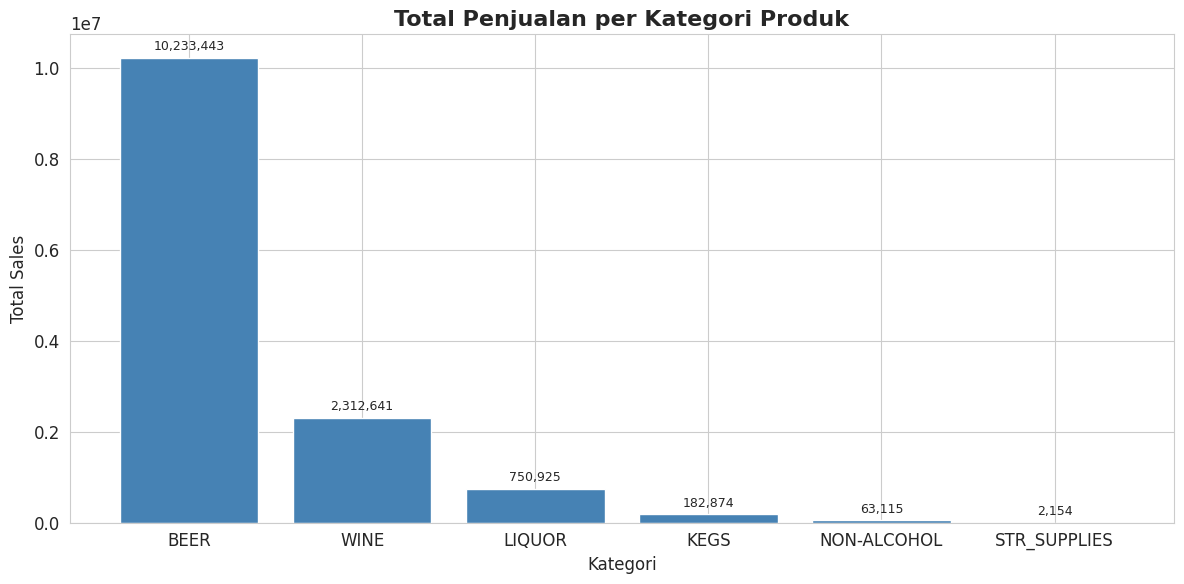

Chart 1 tersimpan!


In [13]:
# Filter hanya kategori dengan nilai positif
item_positive = item_type[item_type['TOTAL SALES'] > 0]

fig, ax = plt.subplots()
bars = ax.bar(item_positive.index, item_positive['TOTAL SALES'], color='steelblue', edgecolor='white')

ax.set_title('Total Penjualan per Kategori Produk', fontsize=16, fontweight='bold')
ax.set_xlabel('Kategori')
ax.set_ylabel('Total Sales')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('chart1_kategori.png', dpi=150)
plt.show()
print("Chart 1 tersimpan!")

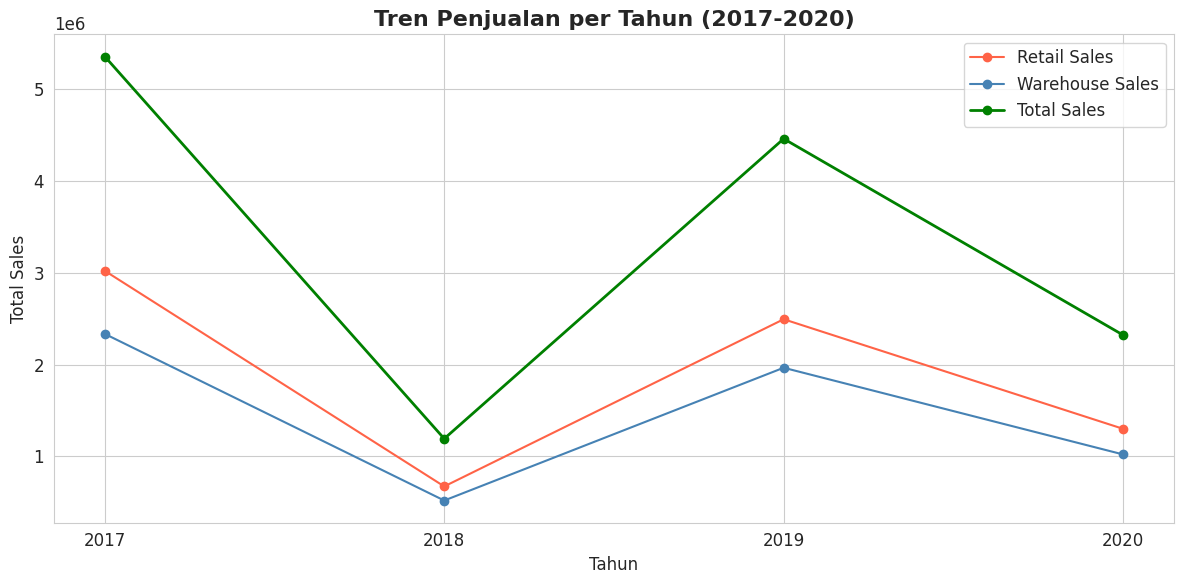

Chart 2 tersimpan!


In [15]:
fig, ax = plt.subplots()

ax.plot(yearly.index, yearly['RETAIL SALES'], marker='o', label='Retail Sales', color='tomato')
ax.plot(yearly.index, yearly['WAREHOUSE SALES'], marker='o', label='Warehouse Sales', color='steelblue')
ax.plot(yearly.index, yearly['TOTAL SALES'], marker='o', label='Total Sales', color='green', linewidth=2)

ax.set_title('Tren Penjualan per Tahun (2017-2020)', fontsize=16, fontweight='bold')
ax.set_xlabel('Tahun')
ax.set_ylabel('Total Sales')
ax.legend()
ax.set_xticks([2017, 2018, 2019, 2020])

plt.tight_layout()
plt.savefig('chart2_tren_tahun.png', dpi=150)
plt.show()
print("Chart 2 tersimpan!")

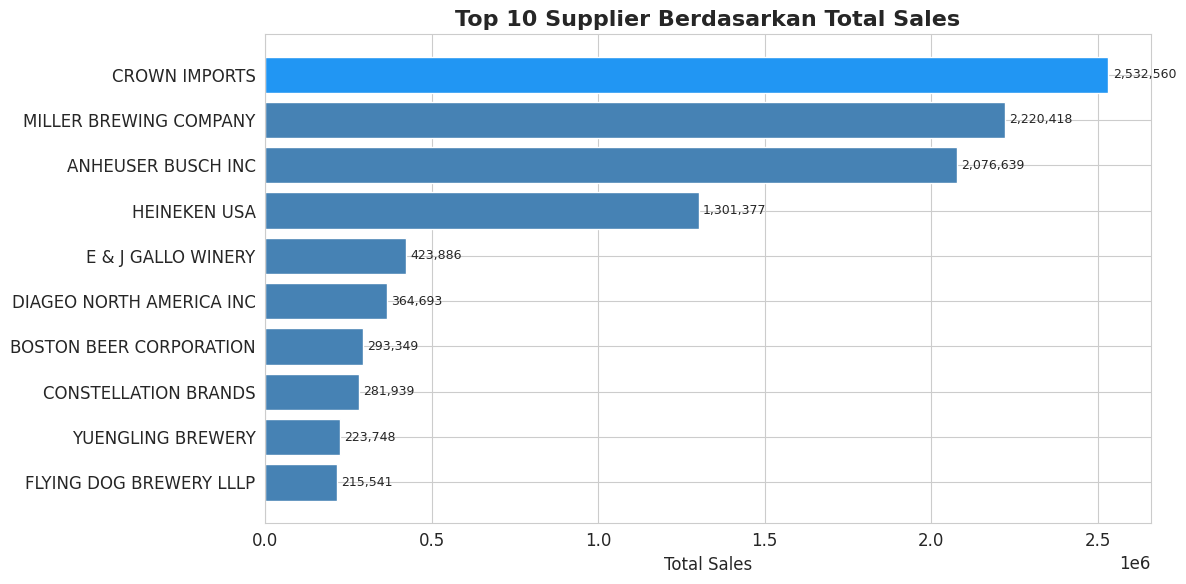

Chart 3 tersimpan!


In [17]:
fig, ax = plt.subplots()

colors = ['#2196F3' if i == 0 else 'steelblue' for i in range(len(top_supplier))]
bars = ax.barh(top_supplier.index[::-1], top_supplier.values[::-1], color=colors[::-1])

ax.set_title('Top 10 Supplier Berdasarkan Total Sales', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Sales')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('chart3_top_supplier.png', dpi=150)
plt.show()
print("Chart 3 tersimpan!")

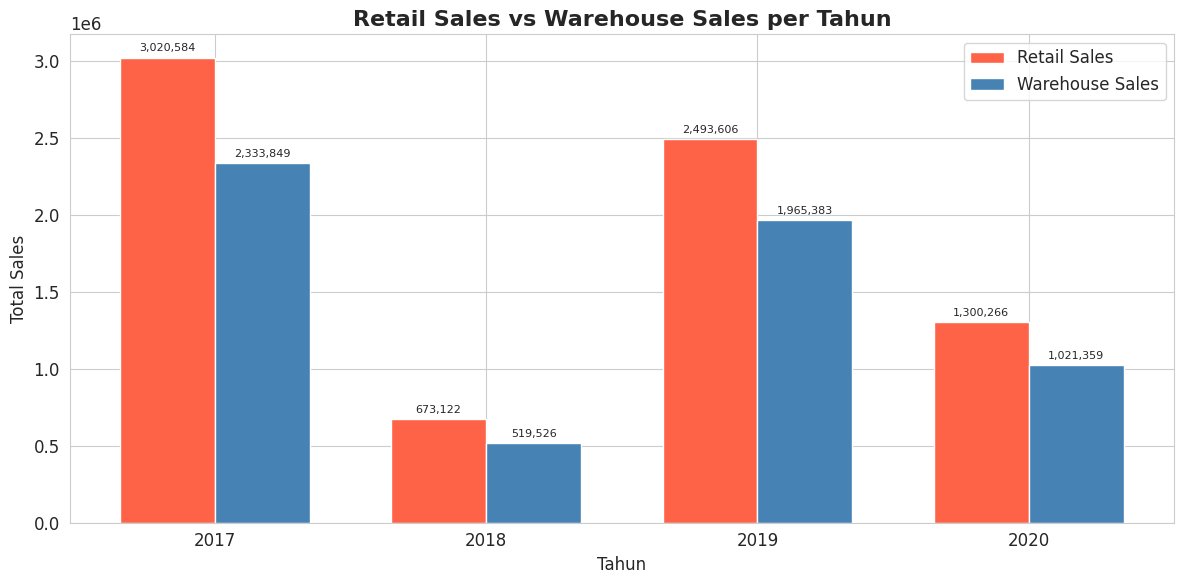

Chart 4 tersimpan!


In [18]:
x = np.arange(len(yearly.index))
width = 0.35

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, yearly['RETAIL SALES'], width, label='Retail Sales', color='tomato')
bars2 = ax.bar(x + width/2, yearly['WAREHOUSE SALES'], width, label='Warehouse Sales', color='steelblue')

ax.set_title('Retail Sales vs Warehouse Sales per Tahun', fontsize=16, fontweight='bold')
ax.set_xlabel('Tahun')
ax.set_ylabel('Total Sales')
ax.set_xticks(x)
ax.set_xticklabels(yearly.index)
ax.legend()
ax.bar_label(bars1, fmt='{:,.0f}', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='{:,.0f}', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('chart4_retail_vs_warehouse.png', dpi=150)
plt.show()
print("Chart 4 tersimpan!")

## Kesimpulan & Insight

### 1. Beer mendominasi pasar
Kategori BEER mencatat total penjualan 10.2 juta — hampir 4x lipat dari WINE (2.3 juta) di posisi kedua. Bisnis sangat bergantung pada kategori ini.

### 2. Anomali penjualan di 2018
Total sales turun drastis dari 5.3 juta (2017) menjadi 1.1 juta (2018) — penurunan ~79%. Perlu investigasi lebih lanjut apakah ini karena perubahan data pencatatan atau faktor bisnis.

### 3. Recovery kuat di 2019
Penjualan kembali naik ke 4.4 juta di 2019, menunjukkan bisnis mampu pulih. Namun kembali turun di 2020 — kemungkinan terdampak pandemi COVID-19.

### 4. Retail lebih dominan dari Warehouse
Di setiap tahun, Retail Sales selalu lebih tinggi dari Warehouse Sales. Ini menunjukkan produk lebih banyak terjual langsung ke konsumen melalui toko ritel.

### 5. Crown Imports adalah supplier terbesar
Dengan total sales 2.5 juta, Crown Imports unggul jauh dari Miller Brewing (2.2 juta) dan Anheuser Busch (2.0 juta).